In [1]:
import time
%matplotlib widget

from scipy.constants import hbar, m_e, eV, physical_constants
## necessary modules
import numpy as np
from tqdm import tqdm
from matplotlib.patches import ConnectionPatch
import random
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy import integrate
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
from pfapack.ctypes import pfaffian as cpf
from scipy import sparse
from scipy.linalg import ishermitian
from OneD_nanowire_utils import construct_Hamil, Diagonalize, Energy_spectrum, wavefunc, Energy_spectrum_phi, Energy_spectrum_v_VQD, pfaffian_calculation, Energy_tracker_phi, Energy_tracker_VQD, Topological_stability, Gen_disorder
from transport_quantities_1D_nanowire import capacitance, Capacitance_vs_phi, Capacitance_vs_VQD, inductance, inductance_vs_phi, inductance_vs_VQD
from config_1D_nanowire import ModelParams
import matplotlib.ticker as ticker
from joblib import Parallel, delayed
from copy import deepcopy

## define the pauli matrices
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
s0 = np.array([[1, 0], [0, 1]]) 

In [2]:
V0 = 0.3
disorder_file = "Disorder_N_300_Broy.txt"
V_dis = V0*np.array(np.loadtxt(open(disorder_file, "rb"), skiprows=0))
S = np.array([[0,0,1,0],[0,0,0,1],[1,0,0,0],[0,1,0,0]])
params = ModelParams(Disorder=V_dis, chirality_op=S)

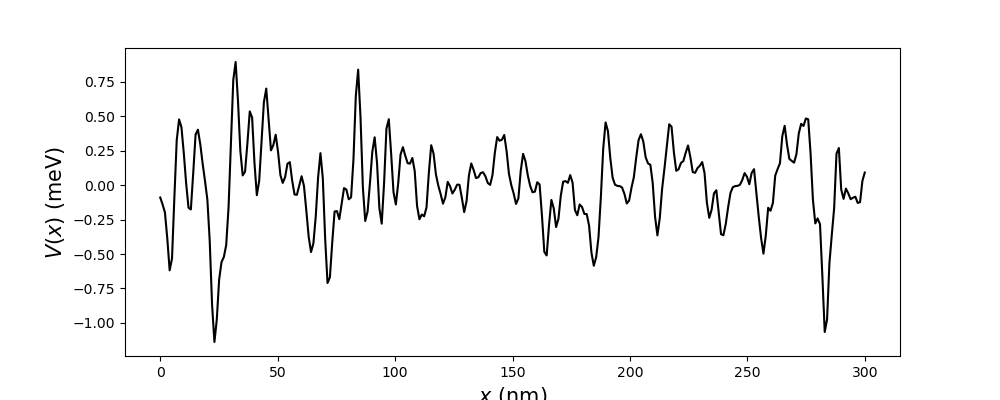

In [3]:
sigma = 70
x0 = 0.0
x1 = params.Length
def Potential(x, V_0):
    return V_0*(
        np.exp(-((int(x/2) - x0) ** 2) / (2 * sigma**2))
        + np.exp(-((x1 - int(x/2)) ** 2) / (2 * sigma**2))
    )

x = np.linspace(0.0,params.Length,params.Length)
pot_V = []
for i in range(0,2*params.Length,2):
    pot_V.append(Potential(i, V0))
pot_V = np.array(pot_V)
#V_dis = pot_V
params = ModelParams(Disorder=V_dis)
fig, ax_v = plt.subplots(figsize=(10, 4))
ax_v.plot(x, params.Disorder, label=r"$V(x)$", color="black")
ax_v.set_xlabel(r"$x$ (nm)", fontsize=15)
ax_v.set_ylabel(r"$V(x)$ (meV)", fontsize=15)
plt.show()

In [47]:
##Local Parameters##
mu_loc = 0.5
Ez_loc = 0.66
V_QD_low_loc = 0.4
V_QD_high_loc = 0.7
V_QD_points_loc = 200
phi_low_loc = 0.0
phi_high_loc = 2.0*np.pi
phi_points_loc = 200
gam_low_loc = 0.0
gam_high_loc = 1.25
gam_points_loc = 200
w_left_loc = 0.025
w_right_loc = 0.025
V_QD_loc = 0.551
No_QD_loc = False
params = ModelParams(
    mu=mu_loc, 
    Ez=Ez_loc, 
    w_left=w_left_loc, 
    w_right=w_right_loc, 
    V_QD_low=V_QD_low_loc, 
    V_QD_high=V_QD_high_loc, 
    V_QD_points=V_QD_points_loc, 
    Ez_low=gam_low_loc, 
    Ez_high=gam_high_loc, 
    Ez_points=gam_points_loc,
    phi_low=phi_low_loc,
    phi_high=phi_high_loc,
    phi_points=phi_points_loc, 
    V_QD=V_QD_loc,
    Disorder=V_dis, 
    chirality_op=S,
                     )
gam_range_loc = np.linspace(gam_low_loc, gam_high_loc, gam_points_loc)
vqd_range_loc = np.linspace(V_QD_low_loc, V_QD_high_loc, V_QD_points_loc)

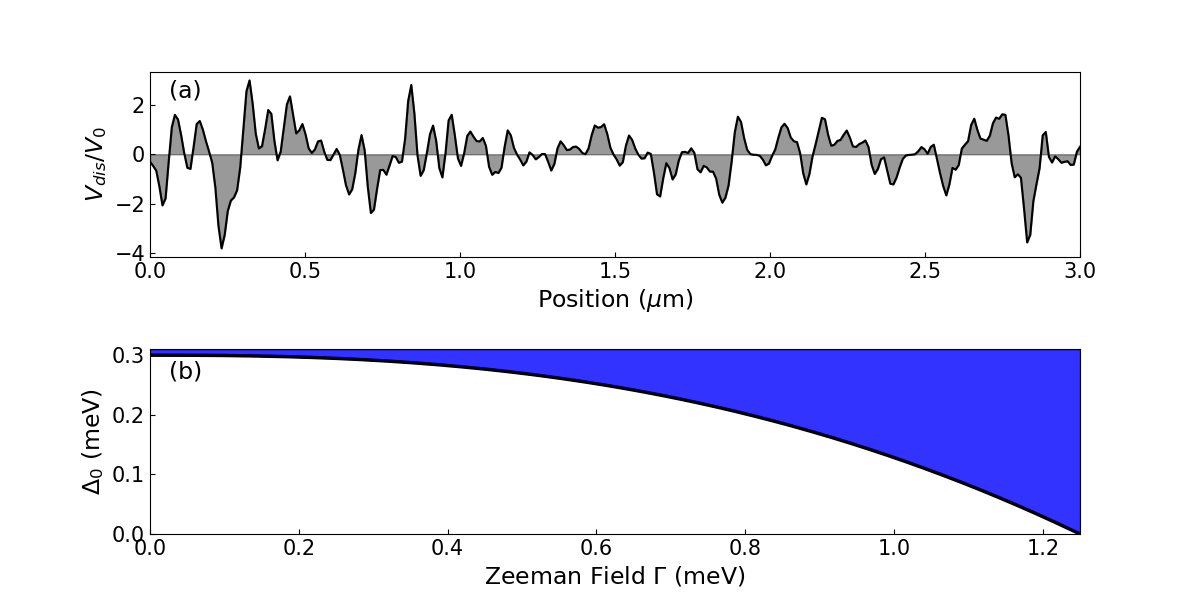

In [70]:
delta_0 = lambda B: 0.3 - 0.17173*(B**2.5)
wire = np.linspace(0.0,3.0,params.Length)

fig = plt.figure(figsize=(12, 6))
gs = GridSpec(2,1, figure=fig, hspace=0.5)

ax_dis = fig.add_subplot(gs[0,0])
ax_dis.plot(wire, V_dis/np.sqrt(np.mean(V_dis**2.0)), '-k', linewidth=1.5)
ax_dis.fill_between(wire, V_dis/np.sqrt(np.mean(V_dis**2.0)), 0.0, color='black', alpha=0.4)
ax_dis.set_ylabel(r"$V_{dis}/V_0$", fontsize=17)
ax_dis.set_xlabel(r"Position ($\mu$m)", fontsize=17)
ax_dis.set_xlim(0.0,3.0)
ax_dis.text(0.02, 0.96, '(a)', transform=ax_dis.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_dis.tick_params(axis='both', which='major', labelsize=15, direction='in')

ax_del = fig.add_subplot(gs[1,0])
ax_del.plot(gam_range_loc, delta_0(gam_range_loc), '-k', linewidth=2.5)
ax_del.fill_between(gam_range_loc, delta_0(gam_range_loc), 0.31, color='blue', alpha=0.8)
ax_del.set_ylabel(r"$\Delta_0$ (meV)", fontsize=17)
ax_del.set_xlabel(r"Zeeman Field $\Gamma$ (meV)", fontsize=17)
ax_del.set_xlim(0.0,1.25)
ax_del.set_ylim(0.0,0.31)
ax_del.text(0.02, 0.94, '(b)', transform=ax_del.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_del.tick_params(axis='both', which='major', labelsize=15, direction='in')

plt.savefig("../Impedance_calc_paper/Plots/Dis_and_delta0_profile.pdf")

In [7]:
def _worker_pf_sweep(Ez0, mu_loc, No_QD, params):
    """Worker function to compute pfaffian for a given \mu over increasing \Gamma"""
    p = deepcopy(params)
    return pfaffian_calculation(mu=mu_loc, Ez=Ez0, No_QD=No_QD, params=p)

In [123]:
#Energy_spectra = Energy_spectrum(mu=mu_loc, params=params, No_QD=True, num_eigvals=100)#np.zeros((50,gam_points_loc))##
#pfaf_1d = Parallel(n_jobs=-1, backend="loky")(
#    delayed(_worker_pf_sweep)(Ez0, mu_loc, True, params)
#    for Ez0 in tqdm(gam_range_loc)
#)
#mf_wf1, mf_wf2, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=No_QD_loc, params=params)
c_params = deepcopy(params)
c_params.V_QD = 0.551
C_vs_phi_even_1, C_vs_phi_odd_1 = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=c_params, number_of_states=200)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
L_vs_phi_even_P_1, L_vs_phi_even_D_1, L_vs_phi_odd_P_1, L_vs_phi_odd_D_1 = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=c_params, number_of_states=200)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
Ep_1, En_1 = Energy_tracker_phi(mu=mu_loc, Ez=Ez_loc, params=c_params)
c_params = deepcopy(params)
c_params.V_QD = 0.518776
C_vs_phi_even_2, C_vs_phi_odd_2 = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=c_params, number_of_states=200)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
L_vs_phi_even_P_2, L_vs_phi_even_D_2, L_vs_phi_odd_P_2, L_vs_phi_odd_D_2 = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=c_params, number_of_states=200)#np.zeros(phi_points_loc), np.zeros(phi_points_loc)#
Ep_2, En_2 = Energy_tracker_phi(mu=mu_loc, Ez=Ez_loc, params=c_params)
#E_vs_vqd, _, _ = Energy_spectrum_v_VQD(mu=mu_loc, Ez=Ez_loc, phi=0.0, params=params)
#E_vqd_p = deepcopy(params)
#E_vqd_p.V_QD_points = 500
#E_vqd_range = np.linspace(E_vqd_p.V_QD_low, E_vqd_p.V_QD_high, E_vqd_p.V_QD_points)
#Ep_0, En_0 = Energy_tracker_VQD(mu=mu_loc, Ez=Ez_loc, phi0=0.0, params=E_vqd_p)
#Ep_pi, En_pi = Energy_tracker_VQD(mu=mu_loc, Ez=Ez_loc, phi0=np.pi, params=E_vqd_p)
#p_transport = deepcopy(params)
#p_transport.V_QD_low=0.49
#p_transport.V_QD_high=0.62
#vqd_transport_range = np.linspace(p_transport.V_QD_low, p_transport.V_QD_high, p_transport.V_QD_points)
#C_vs_vqd_0, C_vs_vqd_pi = Capacitance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=p_transport, number_of_states=200)
#L_vs_vqd_P_0, L_vs_vqd_D_0, L_vs_vqd_P_pi, L_vs_vqd_D_pi = inductance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=p_transport, number_of_states=200)

phi eigs: 100%|██████████| 200/200 [00:00<00:00, 63632.01it/s]


In [ ]:
output_dir = "Paper_result_files/"
np.savetxt(output_dir+"_energy_spectrum_mu_05_Gamma_0_125.txt", Energy_spectra)
np.savetxt(output_dir+"_energy_spectrum_mu_05_pfaffian.txt", np.array(pfaf_1d))
np.savetxt(output_dir+"_energy_versus_VQD_mu_05_Gamma_065.txt", np.array([E_vqd_range, Ep_0, En_0]))
np.savetxt(output_dir+"_delta_capacitance_0_mu_05_Gamma_065.txt", C_vs_vqd_0)
np.savetxt(output_dir+"_delta_capacitance_pi_mu_05_Gamma_065.txt", C_vs_vqd_pi)
np.savetxt(output_dir+"_delta_inductance_P_0_mu_05_Gamma_065.txt", L_vs_vqd_P_0)
np.savetxt(output_dir+"_delta_inductance_D_0_mu_05_Gamma_065.txt", L_vs_vqd_D_0)
np.savetxt(output_dir+"_delta_inductance_P_pi_mu_05_Gamma_065.txt", L_vs_vqd_P_pi)
np.savetxt(output_dir+"_delta_inductance_D_pi_mu_05_Gamma_065.txt", L_vs_vqd_D_pi)

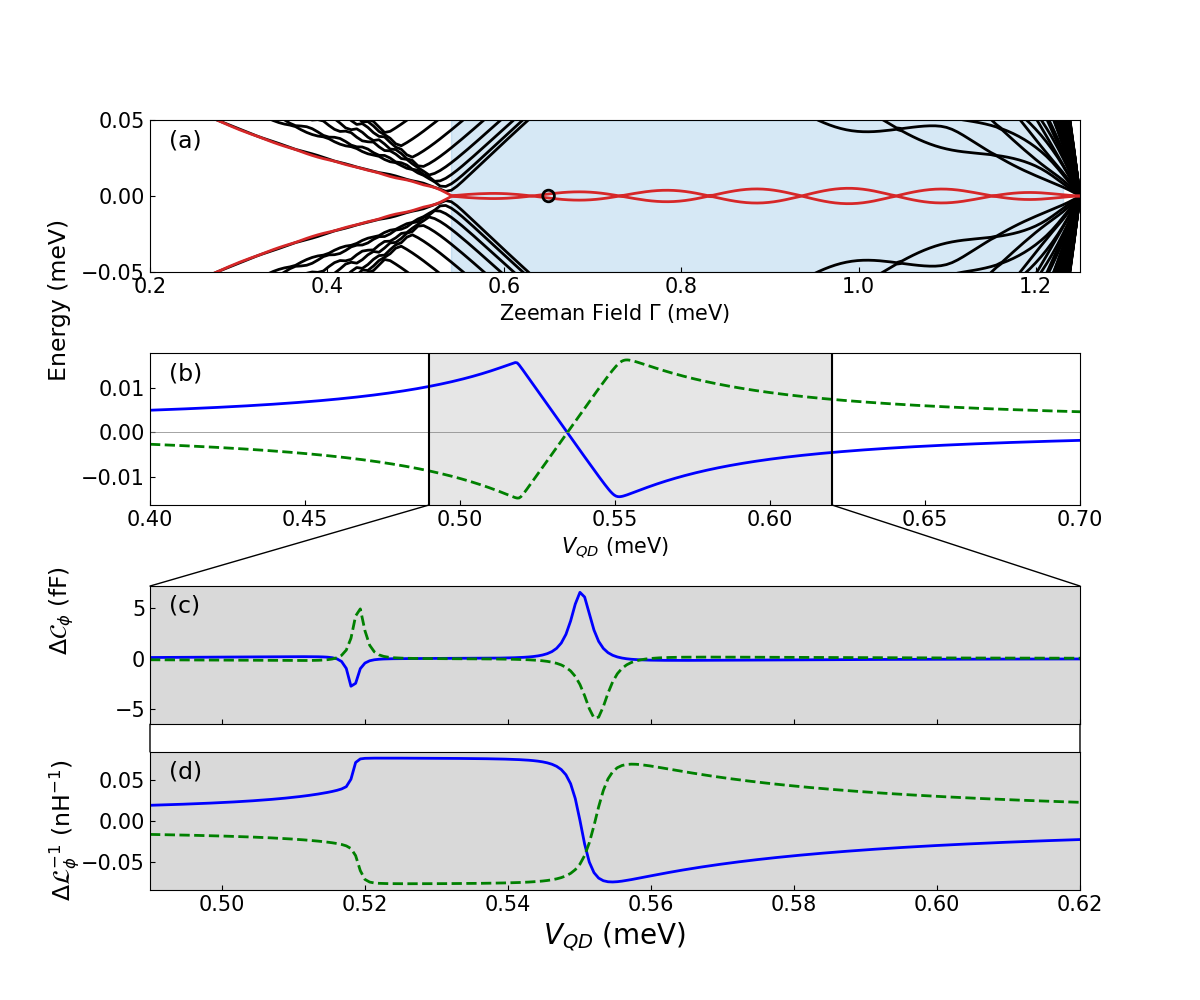

In [ ]:
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(3,1, figure=fig, height_ratios=[1, 1, 2], hspace=0.4)

label_size=15

ax_Espec = fig.add_subplot(gs[0,0])
for i in range(len(Energy_spectra[0])):
        if (i != 49 and i != 50):
                ax_Espec.plot(gam_range_loc, Energy_spectra[:, i], "k", lw=2.0)
ax_Espec.plot(gam_range_loc, Energy_spectra[:, 49], color='#d62728', linestyle='solid', lw=2.0)
ax_Espec.plot(gam_range_loc, Energy_spectra[:, 50],  color='#d62728', linestyle='solid', lw=2.0)
ax_Espec.set_ylim(-0.05,0.05)
ax_Espec.fill_between(gam_range_loc, -0.05, 0.05, where=(np.array(pfaf_1d)<0.0), color='#5DA5DA', alpha=0.25)
ax_Espec.tick_params(axis='both', which='major', labelsize=15, direction='in')
#ax_Espec.set_ylabel("Energy (meV)", fontsize=label_size)
ax_Espec.set_xlabel(r"Zeeman Field $\Gamma$ (meV)", fontsize=label_size)
ax_Espec.text(0.02, 0.94, '(a)', transform=ax_Espec.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Espec.set_xlim(0.2,gam_high_loc)
#ax_Espec.set_title(r"Energy Spectrum for $\mu = $"+str(np.round(mu_loc,2))+" meV")

ax_Espec.scatter(0.65, 0.0, marker="o", s=70.0, facecolors='none' ,edgecolors='black', zorder=2, linewidth=2.0)

ax_Evqd = fig.add_subplot(gs[1,0])
ax_Evqd.plot(E_vqd_range, Ep_0, 'b-', linewidth=2.0)
ax_Evqd.plot(E_vqd_range, En_pi, 'g--', linewidth=2.0)
ax_Evqd.axhline(0, color='gray', linewidth=0.5)
ax_Evqd.axvline(0.49, color='black', linewidth=1.5)
ax_Evqd.axvline(0.62, color='black', linewidth=1.5)
ax_Evqd.axvspan(0.49,0.62, color='0.9', zorder=-1)
#ax_Evqd.set_ylim(-0.05,0.05)
ax_Evqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Evqd.text(0.02, 0.94, '(b)', transform=ax_Evqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
#ax_Evqd.set_ylabel("Energy (meV)", fontsize=label_size)
ax_Evqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size)
ax_Evqd.set_xlim(E_vqd_p.V_QD_low, E_vqd_p.V_QD_high)
#ax_Evqd.set_title(r"Energy versus $V_{QD}$ for $\mu = $"+str(np.round(mu_loc,2))+" meV")

gs_bottom = gridspec.GridSpecFromSubplotSpec(2,1, subplot_spec=gs[2, 0], hspace=0.2)
ax_Cvqd = fig.add_subplot(gs_bottom[0,0])
ax_Cvqd.plot(vqd_transport_range, C_vs_vqd_0, 'b-', linewidth=2.0, label=r"$\phi=0$")
ax_Cvqd.plot(vqd_transport_range, C_vs_vqd_pi, 'g--', linewidth=2.0, label=r"$\phi=\pi$")
#ax_Cvqd.set_ylabel(r"$\Delta \mathcal{C}_\phi$ (fF)", fontsize=label_size+3)
#ax_Cvqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size)
ax_Cvqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Cvqd.text(0.02, 0.94, '(c)', transform=ax_Cvqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Cvqd.set_xlim(p_transport.V_QD_low, p_transport.V_QD_high)
ax_Cvqd.set_facecolor('0.85')

ax_Lvqd = fig.add_subplot(gs_bottom[1,0], sharex=ax_Cvqd)
ax_Lvqd.plot(vqd_transport_range, L_vs_vqd_P_0 + L_vs_vqd_D_0, 'b-', linewidth=2.0, label=r"$\phi=0$")
ax_Lvqd.plot(vqd_transport_range, L_vs_vqd_P_pi + L_vs_vqd_D_pi, 'g--', linewidth=2.0, label=r"$\phi=\pi$")
#ax_Lvqd.set_ylabel(r"$\Delta \mathcal{L}^{-1}_\phi$ (n$\mathrm{H}^{-1}$)", fontsize=label_size+3)
ax_Lvqd.set_xlabel(r"$V_{QD}$ (meV)", fontsize=label_size+5)
ax_Lvqd.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Lvqd.text(0.02, 0.94, '(d)', transform=ax_Lvqd.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Lvqd.set_xlim(p_transport.V_QD_low, p_transport.V_QD_high)
ax_Lvqd.set_facecolor('0.85')

yl_top = ax_Evqd.get_ylim()
yl_bot1 = ax_Cvqd.get_ylim()
yl_bot2 = ax_Lvqd.get_ylim()

plt.setp(ax_Cvqd.get_xticklabels(), visible=False)
plt.setp(ax_Lvqd.get_xticklabels(), visible=True)

con_left = ConnectionPatch(
        xyA = (0.49, yl_top[0]), coordsA=ax_Evqd.transData,
        xyB = (0.49, yl_bot1[1]), coordsB=ax_Cvqd.transData,
        color='black',
)

con_right = ConnectionPatch(
        xyA = (0.62, yl_top[0]), coordsA=ax_Evqd.transData,
        xyB = (0.62, yl_bot1[1]), coordsB=ax_Cvqd.transData,
        color='black',
)

con_left_2 = ConnectionPatch(
        xyA = (0.49, yl_bot1[0]), coordsA=ax_Cvqd.transData,
        xyB = (0.49, yl_bot2[1]), coordsB=ax_Lvqd.transData,
        color='black',
)

con_right_2 = ConnectionPatch(
        xyA = (0.62, yl_bot1[0]), coordsA=ax_Cvqd.transData,
        xyB = (0.62, yl_bot2[1]), coordsB=ax_Lvqd.transData,
        color='black',
)

fig.text(0.04, 0.7, "Energy (meV)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.39, r"$\Delta \mathcal{C}_\phi$ (fF)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.17, r"$\Delta \mathcal{L}^{-1}_\phi$ (n$\mathrm{H}^{-1}$)", rotation="vertical", va="center", fontsize=17)
fig.add_artist(con_left)
fig.add_artist(con_right)
fig.add_artist(con_left_2)
fig.add_artist(con_right_2)

#plt.savefig("../Impedance_calc_paper/Plots/Clean_sys_energy_and_transport_TpRegime.pdf")

plt.show()

In [ ]:
output_dir = "Paper_result_files/"
np.savetxt(output_dir+"_energy_versus_phi_vqd_551_mu_05_Gamma_065.txt", np.array([Ep_1, En_1]))
np.savetxt(output_dir+"_energy_versus_phi_vqd_512_mu_05_Gamma_065.txt", np.array([Ep_2, En_2]))
np.savetxt(output_dir+"_delta_capacitance_versus_phi_551_mu_05_Gamma_065.txt", np.array([C_vs_phi_even_1, C_vs_phi_odd_1]))
np.savetxt(output_dir+"_delta_capacitance_versus_phi_512_mu_05_Gamma_065.txt", np.array([C_vs_phi_even_2, C_vs_phi_odd_2]))
np.savetxt(output_dir+"_delta_inductance_versus_phi_P_551_mu_05_Gamma_065.txt", np.array([L_vs_phi_even_P_1, L_vs_phi_odd_P_1]))
np.savetxt(output_dir+"_delta_inductance_versus_phi_D_551_mu_05_Gamma_065.txt", np.array([L_vs_phi_even_D_1, L_vs_phi_odd_D_1]))
np.savetxt(output_dir+"_delta_inductance_versus_phi_P_512_mu_05_Gamma_065.txt", np.array([L_vs_phi_even_P_2, L_vs_phi_odd_P_2]))
np.savetxt(output_dir+"_delta_inductance_versus_phi_D_512_mu_05_Gamma_065.txt", np.array([L_vs_phi_even_D_2, L_vs_phi_odd_D_2]))

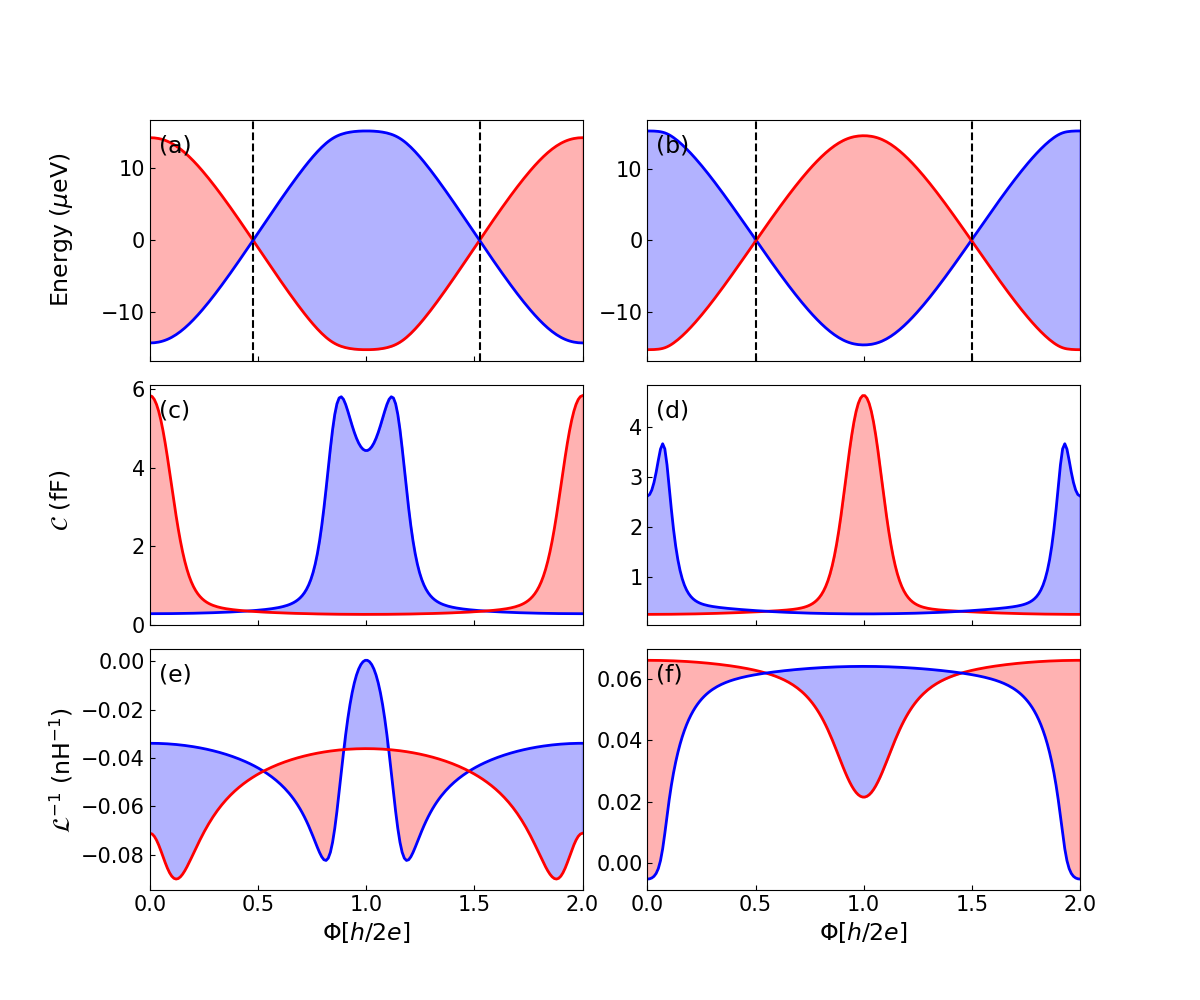

In [159]:
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(3,2, figure=fig, hspace=0.1, wspace=0.15)

angles = np.linspace(0.0, 2.0, phi_points_loc)

#Ep_1, En_1, Ep_2, En_2 = Ep_1/1000.0, En_1/1000.0, Ep_2/1000.0, En_2/1000.0

ax_Evphi_1 = fig.add_subplot(gs[0,0])
ax_Evphi_1.plot(angles, Ep_1, 'r-', lw=2.0)
ax_Evphi_1.plot(angles, En_1, 'b-', lw=2.0)
ax_Evphi_1.fill_between(angles, Ep_1, En_1, where=(Ep_1>0.0), color='red', alpha=0.3)
ax_Evphi_1.fill_between(angles, Ep_1, En_1, where=(En_1>0.0), color='blue', alpha=0.3)
ax_Evphi_1.axvline(1.4968/np.pi, linestyle='dashed', color='black')
ax_Evphi_1.axvline(4.7863/np.pi, linestyle='dashed', color='black')
ax_Evphi_1.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Evphi_1.text(0.02, 0.94, '(a)', transform=ax_Evphi_1.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Evphi_1.set_xlim(0.0,2.0)

ax_Evphi_2 = fig.add_subplot(gs[0,1])
ax_Evphi_2.plot(angles, Ep_2, 'b-', lw=2.0)
ax_Evphi_2.plot(angles, En_2, 'r-', lw=2.0)
ax_Evphi_2.fill_between(angles, Ep_2, En_2, where=(Ep_2>0.0), color='blue', alpha=0.3)
ax_Evphi_2.fill_between(angles, Ep_2, En_2, where=(En_2>0.0), color='red', alpha=0.3)
ax_Evphi_2.axvline(0.5, linestyle='dashed', color='black')
ax_Evphi_2.axvline(1.5, linestyle='dashed', color='black')
ax_Evphi_2.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Evphi_2.text(0.02, 0.94, '(b)', transform=ax_Evphi_2.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Evphi_2.set_xlim(0.0,2.0)

ax_Cvphi_1 = fig.add_subplot(gs[1,0])
ax_Cvphi_1.plot(angles, C_vs_phi_even_1, 'b-', lw=2.0)
ax_Cvphi_1.plot(angles, C_vs_phi_odd_1, 'r-', lw=2.0)
ax_Cvphi_1.fill_between(angles, C_vs_phi_even_1, C_vs_phi_odd_1, where=(C_vs_phi_even_1<C_vs_phi_odd_1), color='red', alpha=0.3)
ax_Cvphi_1.fill_between(angles, C_vs_phi_even_1, C_vs_phi_odd_1, where=(C_vs_phi_even_1>C_vs_phi_odd_1), color='blue', alpha=0.3)
ax_Cvphi_1.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Cvphi_1.text(0.02, 0.94, '(c)', transform=ax_Cvphi_1.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Cvphi_1.set_xlim(0.0,2.0)

ax_Cvphi_2 = fig.add_subplot(gs[1,1])
ax_Cvphi_2.plot(angles, C_vs_phi_even_2, 'r-', lw=2.0)
ax_Cvphi_2.plot(angles, C_vs_phi_odd_2, 'b-', lw=2.0)
ax_Cvphi_2.fill_between(angles, C_vs_phi_even_2, C_vs_phi_odd_2, where=(C_vs_phi_even_2>C_vs_phi_odd_2), color='red', alpha=0.3)
ax_Cvphi_2.fill_between(angles, C_vs_phi_even_2, C_vs_phi_odd_2, where=(C_vs_phi_even_2<C_vs_phi_odd_2), color='blue', alpha=0.3)
ax_Cvphi_2.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Cvphi_2.text(0.02, 0.94, '(d)', transform=ax_Cvphi_2.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Cvphi_2.set_xlim(0.0,2.0)

L_vs_phi_even_1 = L_vs_phi_even_P_1 + L_vs_phi_even_D_1
L_vs_phi_odd_1 = L_vs_phi_odd_P_1 + L_vs_phi_odd_D_1

ax_Lvphi_1 = fig.add_subplot(gs[2,0])
ax_Lvphi_1.plot(angles, L_vs_phi_even_1, 'b-', lw=2.0)
ax_Lvphi_1.plot(angles, L_vs_phi_odd_1, 'r-', lw=2.0)
ax_Lvphi_1.fill_between(angles, L_vs_phi_even_1, L_vs_phi_odd_1, where=(L_vs_phi_even_1<L_vs_phi_odd_1), color='red', alpha=0.3)
ax_Lvphi_1.fill_between(angles, L_vs_phi_even_1, L_vs_phi_odd_1, where=(L_vs_phi_even_1>L_vs_phi_odd_1), color='blue', alpha=0.3)
ax_Lvphi_1.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Lvphi_1.text(0.02, 0.94, '(e)', transform=ax_Lvphi_1.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Lvphi_1.set_xlim(0.0,2.0)
ax_Lvphi_1.set_xlabel(r"$\Phi [h/2e]$", fontsize=17)

L_vs_phi_even_2 = L_vs_phi_even_P_2 + L_vs_phi_even_D_2
L_vs_phi_odd_2 = L_vs_phi_odd_P_2 + L_vs_phi_odd_D_2

ax_Lvphi_2 = fig.add_subplot(gs[2,1])
ax_Lvphi_2.plot(angles, L_vs_phi_even_2, 'r-', lw=2.0)
ax_Lvphi_2.plot(angles, L_vs_phi_odd_2, 'b-', lw=2.0)
ax_Lvphi_2.fill_between(angles, L_vs_phi_even_2, L_vs_phi_odd_2, where=(L_vs_phi_even_2>L_vs_phi_odd_2), color='red', alpha=0.3)
ax_Lvphi_2.fill_between(angles, L_vs_phi_even_2, L_vs_phi_odd_2, where=(L_vs_phi_even_2<L_vs_phi_odd_2), color='blue', alpha=0.3)
ax_Lvphi_2.tick_params(axis='both', which='major', labelsize=15, direction='in')
ax_Lvphi_2.text(0.02, 0.94, '(f)', transform=ax_Lvphi_2.transAxes, fontsize=17, verticalalignment='top', horizontalalignment='left')
ax_Lvphi_2.set_xlim(0.0,2.0)
ax_Lvphi_2.set_xlabel(r"$\Phi [h/2e]$", fontsize=17)

plt.setp(ax_Evphi_1.get_xticklabels(), visible=False)
plt.setp(ax_Evphi_2.get_xticklabels(), visible=False)
plt.setp(ax_Cvphi_1.get_xticklabels(), visible=False)
plt.setp(ax_Cvphi_2.get_xticklabels(), visible=False)
plt.setp(ax_Lvphi_1.get_xticklabels(), visible=True)
plt.setp(ax_Lvphi_2.get_xticklabels(), visible=True)

fig.text(0.04, 0.77, r"Energy ($\mu$eV)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.5, r"$\mathcal{C}$ (fF)", rotation="vertical", va="center", fontsize=17)
fig.text(0.04, 0.23, r"$\mathcal{L}^{-1}$ (n$\mathrm{H}^{-1}$)", rotation="vertical", va="center", fontsize=17)

plt.savefig("../Impedance_calc_paper/Plots/Clean_sys_transport_vqds_TpRegime.pdf")

plt.show()

In [21]:
def worker_ts_sweep(w_avg, mu_loc, gam_range_loc, No_QD_loc, params):
    """Worker function to compute Topological_stability for a given tunnel strength"""
    p = deepcopy(params)
    p.w_left = p.w_right = w_avg
    Ts_gam_sweep = []
    for Ez0 in gam_range_loc:
        Ts_gam_sweep.append(Topological_stability(mu_loc, Ez0, No_QD_loc, p))
    return Ts_gam_sweep

tunnel_strength_range = np.logspace(-3.0, np.log10(0.5), V_QD_points_loc)
# Parallelize the outer loop (tunnel strength range)
Ts_sweep = Parallel(n_jobs=-1, backend="loky")(
    delayed(worker_ts_sweep)(w_avg, mu_loc, gam_range_loc, No_QD_loc, deepcopy(params))
    for w_avg in tqdm(tunnel_strength_range)
)

100%|██████████| 50/50 [04:18<00:00,  5.16s/it]


In [22]:
from scipy.interpolate import interp1d, RectBivariateSpline
Ts_sweep = np.array(Ts_sweep)

f = RectBivariateSpline(tunnel_strength_range, gam_range_loc, Ts_sweep)
gam_range_loc_fine = np.linspace(gam_low_loc, gam_high_loc, 500)
tunnel_strength_range_fine = np.logspace(-3.0, np.log10(0.5), 500)

Ts_sweep_fine = f(tunnel_strength_range_fine, gam_range_loc_fine)
print(tunnel_strength_range)

[0.001      0.00113522 0.00128873 0.001463   0.00166083 0.00188541
 0.00214036 0.00242978 0.00275834 0.00313133 0.00355476 0.00403544
 0.00458113 0.0052006  0.00590384 0.00670217 0.00760845 0.00863729
 0.00980524 0.01113113 0.01263631 0.01434503 0.0162848  0.01848687
 0.02098672 0.02382459 0.02704622 0.03070348 0.03485528 0.0395685
 0.04491906 0.05099313 0.05788855 0.06571639 0.07460273 0.0846907
 0.09614279 0.10914347 0.12390213 0.1406565  0.15967643 0.18126829
 0.20577986 0.23360594 0.26519474 0.30105505 0.34176449 0.38797877
 0.44044226 0.5       ]


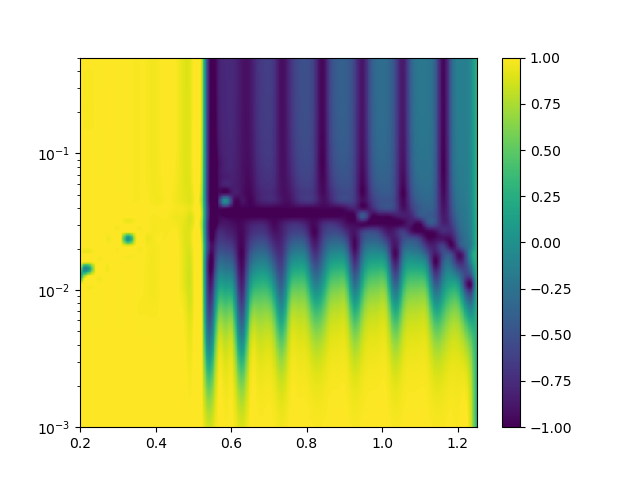

In [24]:
fig, ax_dens = plt.subplots()
angles = np.linspace(0.0, 2.0, params.phi_points)
pcm = ax_dens.pcolor(gam_range_loc_fine, tunnel_strength_range_fine, Ts_sweep_fine, vmin = -1.0, vmax = 1.)
ax_dens.set_yscale('log')
plt.colorbar(pcm)
plt.show()

In [36]:
##Generate txt file
C_vs_phi_even, C_vs_phi_odd = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
L_vs_phi_even_P, L_vs_phi_even_D, L_vs_phi_odd_P, L_vs_phi_odd_D = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
##---With QD couplings---##
Energy_spectra = Energy_spectrum(mu=mu_loc, params=params, No_QD=False)
pfaf_1d = np.zeros(gam_points_loc)
for idx in tqdm(range(gam_points_loc)):
    pfaf_1d[idx] = pfaffian_calculation(mu=mu_loc, Ez=gam_range_loc[idx], No_QD=False, params=params)
mf_wf1, mf_wf2, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=False, params=params)
E_vs_phi, _, _ = Energy_spectrum_phi(mu=mu_loc, Ez=Ez_loc, params=params, No_QD=False)
##Saving results with QD included-
parameter_value = "wd_mu_05_gam_065"
np.savetxt("Impedance_calc_files/Energy_spectra_w_QD_"+parameter_value+".txt",Energy_spectra)
np.savetxt("Impedance_calc_files/Pfafian_spectra_w_QD_"+parameter_value+".txt",pfaf_1d)
np.savetxt("Impedance_calc_files/E_vs_phi_w_QD_"+parameter_value+".txt",E_vs_phi)
np.savetxt("Impedance_calc_files/Wavefunction_1_w_QD_"+parameter_value+".txt",mf_wf1)
np.savetxt("Impedance_calc_files/Wavefunction_2_w_QD_"+parameter_value+".txt",mf_wf2)
##---Without QD couplings---##
Energy_spectra = Energy_spectrum(mu=mu_loc, params=params, No_QD=True)
pfaf_1d = np.zeros(gam_points_loc)
for idx in tqdm(range(gam_points_loc)):
    pfaf_1d[idx] = pfaffian_calculation(mu=mu_loc, Ez=gam_range_loc[idx], No_QD=True, params=params)
mf_wf1, mf_wf2, _, _, _ = wavefunc(mu=mu_loc, Ez=Ez_loc, phi0=0.0, No_QD=True, params=params)
E_vs_phi, _, _ = Energy_spectrum_phi(mu=mu_loc, Ez=Ez_loc, params=params, No_QD=True, end_hopping=True)
##Saving results without QD included-
np.savetxt("Impedance_calc_files/Energy_spectra_wo_QD_"+parameter_value+".txt",Energy_spectra)
np.savetxt("Impedance_calc_files/Pfafian_spectra_wo_QD_"+parameter_value+".txt",pfaf_1d)
np.savetxt("Impedance_calc_files/E_vs_phi_wo_QD_"+parameter_value+".txt",E_vs_phi)
np.savetxt("Impedance_calc_files/Wavefunction_1_wo_QD_"+parameter_value+".txt",mf_wf1)
np.savetxt("Impedance_calc_files/Wavefunction_2_wo_QD_"+parameter_value+".txt",mf_wf2)
##Common calculations
C_vs_VQD_phi_0, C_vs_VQD_phi_pi = Capacitance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
L_vs_VQD_phi_P_0, L_vs_VQD_phi_D_0, L_vs_VQD_phi_P_pi, L_vs_VQD_phi_D_pi = inductance_vs_VQD(mu=mu_loc, Ez=Ez_loc, params=params, number_of_states=200)
##Saving common files
np.savetxt("Impedance_calc_files/Capacitance_even_"+parameter_value+".txt",C_vs_phi_even)
np.savetxt("Impedance_calc_files/Capacitance_odd_"+parameter_value+".txt",C_vs_phi_odd)
np.savetxt("Impedance_calc_files/Capacitance_v_VQD_phi_0_"+parameter_value+".txt",C_vs_VQD_phi_0)
np.savetxt("Impedance_calc_files/Capacitance_v_VQD_phi_pi_"+parameter_value+".txt",C_vs_VQD_phi_pi)
np.savetxt("Impedance_calc_files/Impedance_even_D_"+parameter_value+".txt",L_vs_phi_even_D)
np.savetxt("Impedance_calc_files/Impedance_even_P_"+parameter_value+".txt",L_vs_phi_even_P)
np.savetxt("Impedance_calc_files/Impedance_odd_D_"+parameter_value+".txt",L_vs_phi_odd_D)
np.savetxt("Impedance_calc_files/Impedance_odd_P_"+parameter_value+".txt",L_vs_phi_odd_P)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_0_D_"+parameter_value+".txt",L_vs_VQD_phi_D_0)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_0_P_"+parameter_value+".txt",L_vs_VQD_phi_P_0)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_pi_D_"+parameter_value+".txt",L_vs_VQD_phi_D_pi)
np.savetxt("Impedance_calc_files/Impedance_v_VQD_phi_pi_P_"+parameter_value+".txt",L_vs_VQD_phi_P_pi)

100%|██████████| 150/150 [06:10<00:00,  2.47s/it]


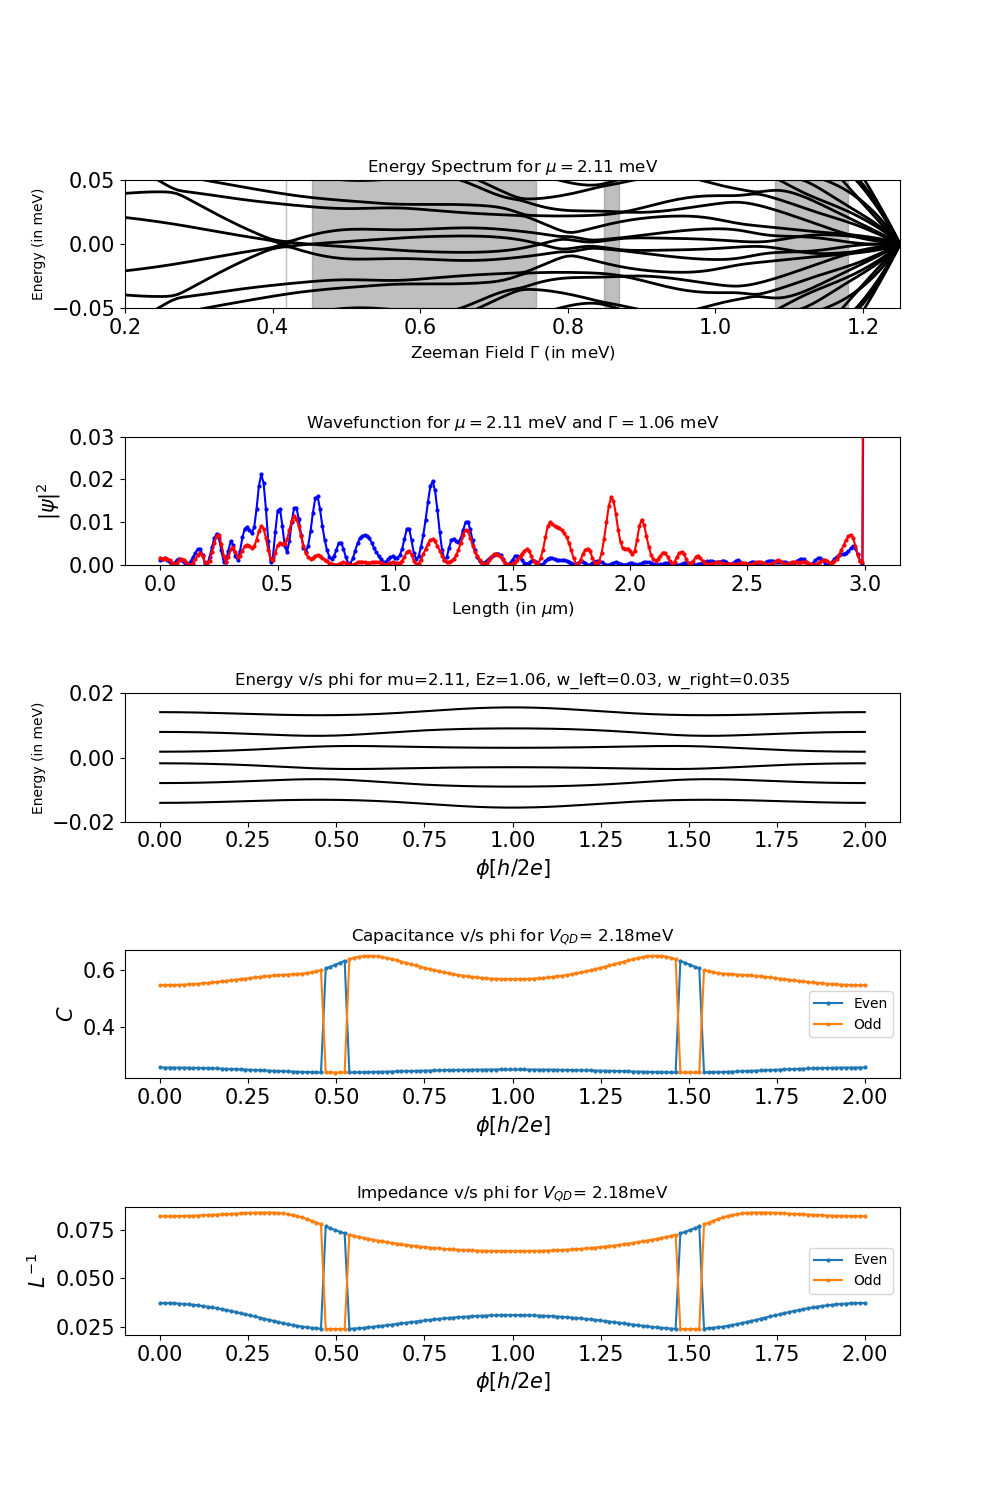

In [59]:
##Plotting all quantities together
fig = plt.figure(figsize=(10, 15))
gs = GridSpec(5,1, figure=fig, hspace=1.)

local_length = params.Length
if not No_QD_loc:
        local_length = params.Length + 1
wire_length = np.linspace(0.0,3.0,local_length)
#angles = np.linspace(params.phi_low, params.phi_high, params.phi_points)
angles = np.linspace(0.0, 2.0, params.phi_points)

ax1 = fig.add_subplot(gs[0,0])
for i in range(len(Energy_spectra[0])):
        ax1.plot(gam_range_loc, Energy_spectra[:, i], "k", lw=2.0)
ax1.set_ylim(-0.05,0.05)
ax1.fill_between(gam_range_loc, -0.05, 0.05, where=(pfaf_1d<0.0), color='gray', alpha=0.5)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax1.set_ylabel("Energy (in meV)")
ax1.set_xlabel(r"Zeeman Field $\Gamma$ (in meV)", fontsize=12)
ax1.set_xlim(gam_low_loc,gam_high_loc)
ax1.set_title(r"Energy Spectrum for $\mu = $"+str(np.round(mu_loc,2))+" meV")

ax2 = fig.add_subplot(gs[1,0])
ax2.plot(wire_length, mf_wf1, 'o-', color='blue', markersize=2.0)
ax2.plot(wire_length, mf_wf2, 'o-', color='red', markersize=2.0)
ax2.set_ylim(0.0, 0.03)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.set_ylabel(r"$\vert\psi\vert^2$", fontsize=15)
ax2.set_xlabel(r"Length (in $\mu$m)", fontsize=12)
ax2.set_title(r"Wavefunction for $\mu = $"+str(np.round(mu_loc,2))+r" meV and $\Gamma = $"+str(np.round(Ez_loc,2))+" meV")

ax3e = fig.add_subplot(gs[2,0])
for i in range(len(E_vs_phi[0])):
        ax3e.plot(angles, E_vs_phi[:, i], "k", lw=1.5)
ax3e.set_ylim(-0.02,0.02)
ax3e.tick_params(axis='both', which='major', labelsize=15)
ax3e.set_ylabel(r"Energy (in meV)")
ax3e.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax3e.set_title(f"Energy v/s phi for mu={mu_loc}, Ez={Ez_loc}, w_left={w_left_loc}, w_right={w_right_loc}")

#Add parity resolved arrays
angle_1 = 0.4595#0.41
angle_2 = 0.5297
angle_3 = 1.4674
angle_4 = 1.5366#1.59
condition_switch = lambda i: False#((angles[i]>=angle_1) and (angles[i]<=angle_4))
condition_double = lambda i: ((angles[i]>=angle_1 and angles[i]<=angle_2) or (angles[i]>=angle_3 and angles[i]<=angle_4))
Ce_parity_resolved, Co_parity_resolved = np.zeros_like(C_vs_phi_even), np.zeros_like(C_vs_phi_odd)
for i in range(len(C_vs_phi_even)):
        Ce_parity_resolved[i] = C_vs_phi_odd[i] if condition_double(i) else C_vs_phi_even[i]
        Co_parity_resolved[i] = C_vs_phi_even[i] if condition_double(i) else C_vs_phi_odd[i]
ax4 = fig.add_subplot(gs[3,0])
ax4.plot(angles, Ce_parity_resolved, '-o', label='Even', markersize=2.0)
ax4.plot(angles, Co_parity_resolved, '-o', label='Odd', markersize=2.0)
ax4.tick_params(axis='both', which='major', labelsize=15)
ax4.set_title(r"Capacitance v/s phi for $V_{QD}$= "+str(np.round(V_QD_loc,2))+"meV")
ax4.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax4.set_ylabel(r'$C$', fontsize=15)
ax4.legend()


#Add parity resolved arrays
#angle_1 = 0.3
#angle_2 = 0.633
#angle_3 = 1.371
#angle_4 = 1.696
condition_switch = lambda i: False#((angles[i]>=angle_1) and (angles[i]<=angle_4))
condition_double = lambda i: ((angles[i]>=angle_1 and angles[i]<=angle_2) or (angles[i]>=angle_3 and angles[i]<=angle_4))
Le_parity_resolved, Lo_parity_resolved = np.zeros_like(L_vs_phi_even_P), np.zeros_like(L_vs_phi_odd_P)
for i in range(len(C_vs_phi_even)):
        Le_parity_resolved[i] = L_vs_phi_odd_P[i] + L_vs_phi_odd_D[i] if condition_double(i) else L_vs_phi_even_P[i] + L_vs_phi_even_D[i]
        Lo_parity_resolved[i] = L_vs_phi_even_P[i] + L_vs_phi_even_D[i] if condition_double(i) else L_vs_phi_odd_P[i] + L_vs_phi_odd_D[i]
ax5 = fig.add_subplot(gs[4,0])
"""
ax5.plot(vqd, d_C0)
ax5.plot(vqd, d_Cpi)
ax5.tick_params(axis = 'both', labelsize=15)
ax5.set_xlabel(r'$V_{QD} (meV)$', fontsize=15)
ax5.set_ylabel(r'$C$', fontsize=15)
#"""
ax5.plot(angles, Le_parity_resolved, '-o', label='Even', markersize=2.0)
ax5.plot(angles, Lo_parity_resolved, '-o', label='Odd', markersize=2.0)
#ax5.plot(VQD_range, L0, label='L0')
#ax5.plot(VQD_range, LPI, label='Lpi')
ax5.tick_params(axis='both', which='major', labelsize=15)
ax5.set_title(r"Impedance v/s phi for $V_{QD}$= "+str(np.round(V_QD_loc,2))+"meV")
ax5.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax5.set_ylabel(r'$L^{-1}$', fontsize=15)
ax5.legend()

#plt.savefig("transport_plots_sanity_checked/Double_crossing_system_profile_mu_22_gamma_0975.pdf")
plt.show()

In [48]:
Delta_C_dens = []
Delta_L_dens = []
for Ez0 in tqdm(gam_range_loc):
    p_gam = deepcopy(params)
    Ce, Co = Capacitance_vs_phi(mu=mu_loc, Ez=Ez0, params=p_gam, number_of_states=50)
    Le_P, Le_D, Lo_P, Lo_D = inductance_vs_phi(mu=mu_loc, Ez=Ez0, params=p_gam, number_of_states=50)
    Delta_C_dens.append(Ce-Co)
    Delta_L_dens.append((Le_P+Le_D) - (Lo_P+Lo_D))
Delta_C_dens = np.array(Delta_C_dens)
Delta_L_dens = np.array(Delta_L_dens)

100%|██████████| 200/200 [22:19<00:00,  6.70s/it]


In [ ]:
from scipy.interpolate import interp1d, RectBivariateSpline

f_C = RectBivariateSpline(angles, gam_range_loc, Delta_C_dens.T)
f_L = RectBivariateSpline(angles, gam_range_loc, Delta_L_dens.T)
gam_range_loc_fine = np.linspace(gam_low_loc, gam_high_loc, 500)
angles_fine = np.linspace(0.0, 2.0, 500)

Delta_C_fine = f_C(angles_fine, gam_range_loc_fine)
Delta_L_fine = f_L(angles_fine, gam_range_loc_fine)

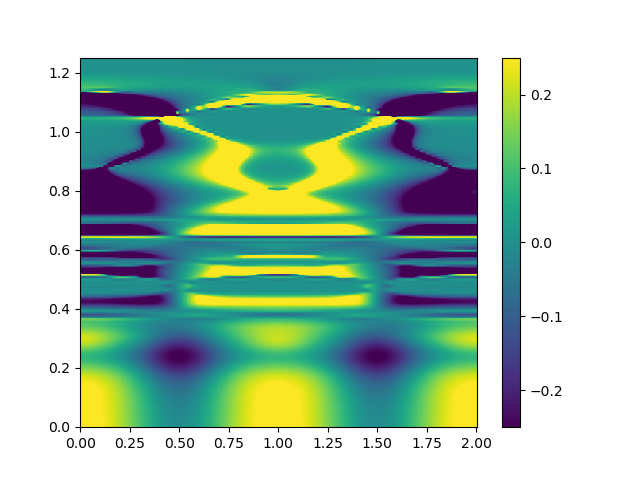

In [34]:
fig, ax_dens = plt.subplots()
angles = np.linspace(0.0, 2.0, params.phi_points)
pcm = ax_dens.pcolor(angles_fine, gam_range_loc_fine, Delta_C_fine.T, vmin=-0.25, vmax=0.25)
#ax_dens.set_yscale('log')
plt.colorbar(pcm)
plt.show()

In [35]:
Delta_C_dens_vqd = []
Delta_L_dens_vqd = []
for vqd0 in tqdm(vqd_range_loc):
    p_gam = deepcopy(params)
    p_gam.V_QD = vqd0
    Ce, Co = Capacitance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_gam, number_of_states=50)
    Le_P, Le_D, Lo_P, Lo_D = inductance_vs_phi(mu=mu_loc, Ez=Ez_loc, params=p_gam, number_of_states=50)
    Delta_C_dens_vqd.append(Ce-Co)
    Delta_L_dens_vqd.append((Le_P+Le_D) - (Lo_P+Lo_D))
Delta_C_dens_vqd = np.array(Delta_C_dens_vqd)
Delta_L_dens_vqd = np.array(Delta_L_dens_vqd)

100%|██████████| 200/200 [20:37<00:00,  6.19s/it]


In [44]:
f_C_vqd = RectBivariateSpline(angles, vqd_range_loc, Delta_C_dens_vqd.T)
f_L_vqd = RectBivariateSpline(angles, vqd_range_loc, Delta_L_dens_vqd.T)
vqd_range_loc_fine = np.linspace(V_QD_low_loc, V_QD_high_loc, 800)
angles_fine = np.linspace(0.0, 2.0, 800)

Delta_C_vqd_fine = f_C_vqd(angles_fine, vqd_range_loc_fine)
Delta_L_vqd_fine = f_L_vqd(angles_fine, vqd_range_loc_fine)

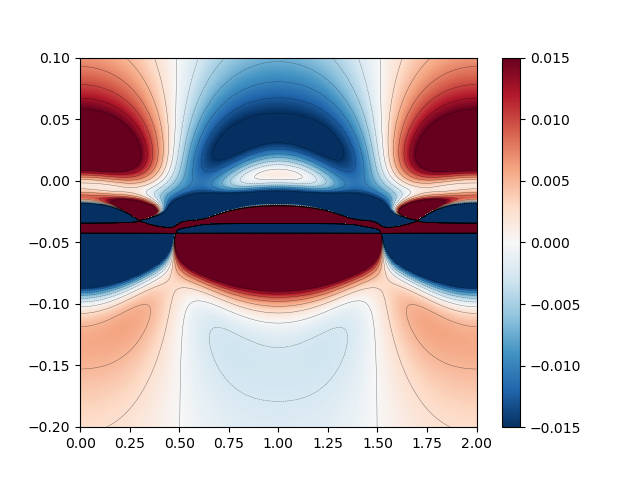

In [52]:
from matplotlib.colors import TwoSlopeNorm
fig, ax_vqd = plt.subplots()
angles = np.linspace(0.0, 2.0, params.phi_points)
norm = TwoSlopeNorm(vmin=-0.015, vcenter=0.0, vmax=0.015)
pcm = ax_vqd.pcolor(angles_fine, mu_loc-vqd_range_loc_fine, Delta_C_vqd_fine.T, cmap='RdBu_r', norm=norm, shading='nearest')
cont = ax_vqd.contour(angles_fine, mu_loc-vqd_range_loc_fine, Delta_C_vqd_fine.T, levels=np.linspace(-0.015, 0.015, 13), colors='k', linewidths=0.3, alpha=0.55)
#ax_dens.set_yscale('log')
plt.colorbar(pcm)
plt.show()

In [53]:
output_dir = "Paper_result_files/"
np.savetxt(output_dir+"Weakly_dis_delta_capacitance_Ez_phi_551_mu_05_Gamma_066.txt", Delta_C_dens)
np.savetxt(output_dir+"Weakly_dis_delta_capacitance_mu_vqd_phi_551_mu_05_Gamma_066.txt", Delta_C_dens_vqd)
np.savetxt(output_dir+"Weakly_dis_delta_inductance_Ez_phi_P_551_mu_05_Gamma_066.txt", Delta_L_dens)
np.savetxt(output_dir+"Weakly_dis_delta_inductance_mu_vqd_phi_D_551_mu_05_Gamma_066.txt", Delta_L_dens_vqd)